In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv('./data/fish_market_500.csv')
df

,length,weight,height,width,species,price
0,11.50,36.3,3.31,1.00,smelt,1355
1,10.77,28.2,3.57,0.84,smelt,3215
2,33.47,950.2,12.63,4.69,bream,25225
3,34.62,753.6,13.55,4.82,bream,20833
4,14.27,22.6,3.43,1.42,smelt,2711
...,...,...,...,...,...,...
495,31.82,643.5,11.39,4.01,bream,19804
496,10.49,24.8,2.90,1.18,smelt,1206
497,33.75,1078.4,10.97,4.16,bream,27986
498,12.82,42.8,3.39,0.85,smelt,3855


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   length   476 non-null    float64
 1   weight   487 non-null    float64
 2   height   482 non-null    float64
 3   width    481 non-null    float64
 4   species  500 non-null    str    
 5   price    500 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 23.6 KB


In [52]:
fill = ['length', 'weight', 'height', 'width']
for col in fill:
    mean_v = df[col].mean() # 해당 컬럼의 평균 계산
    df[col] = df[col].fillna(mean_v, inplace=True) # 평균값으로 결측치 대체

C:\Users\user\AppData\Local\Temp\ipykernel_15484\1481263336.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col] = df[col].fillna(mean_v, inplace=True) # 평균값으로 결측치 대체


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   length   500 non-null    float64
 1   weight   500 non-null    float64
 2   height   500 non-null    float64
 3   width    500 non-null    float64
 4   species  500 non-null    str    
 5   price    500 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 23.6 KB


In [54]:
df.describe().round(1)

,length,weight,height,width,price
count,500.0,500.0,500.0,500.0,500.0
mean,24.6,641.2,8.0,3.0,14262.2
std,11.4,1329.7,4.4,1.7,10794.0
min,7.7,8.4,2.1,0.6,800.0
25%,12.3,31.1,3.3,1.2,2764.5
50%,29.5,703.8,10.5,4.0,21108.0
75%,35.0,928.8,12.2,4.5,24081.2
max,53.0,16477.2,14.2,5.4,31048.0


In [55]:
df['species'].unique()

<StringArray>
['smelt', 'bream']
Length: 2, dtype: str

In [56]:
# 데이터 시각화를 위해 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

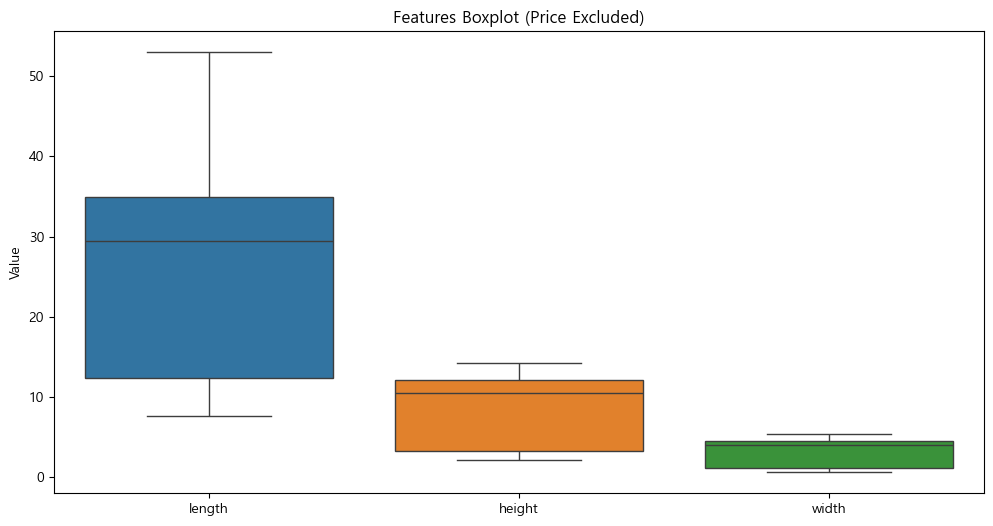

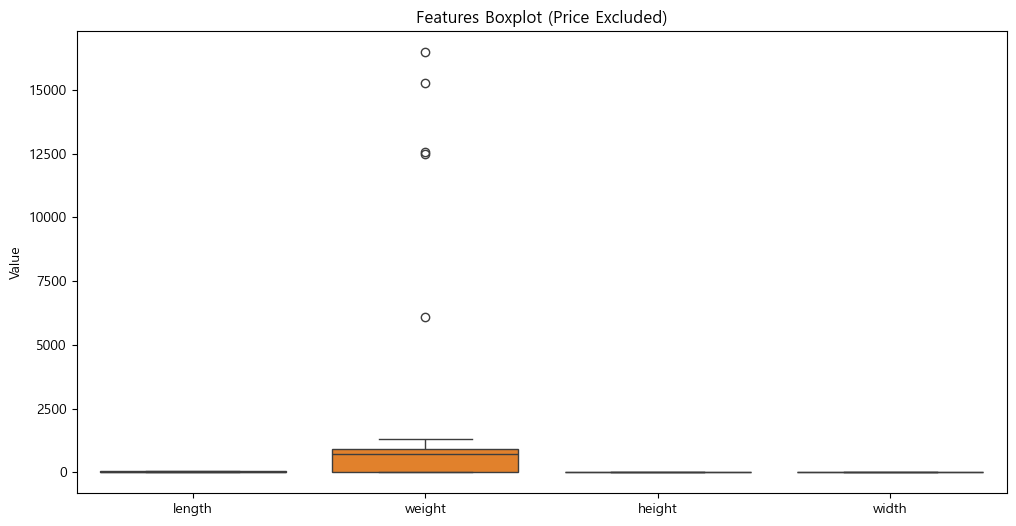

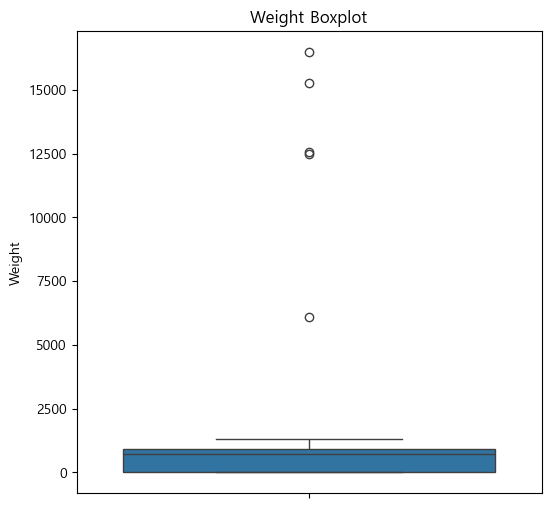

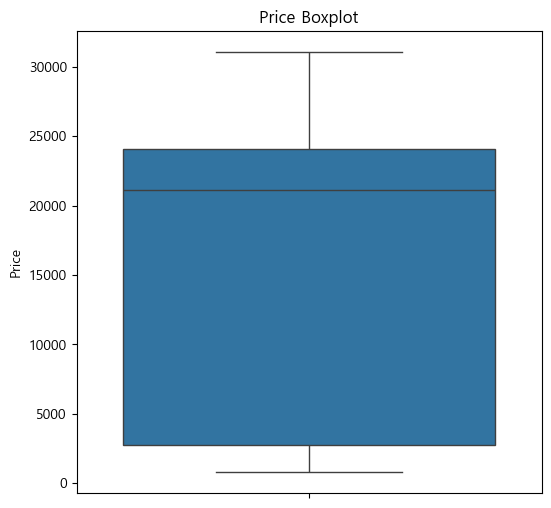

In [ ]:
feature = ['length', 'height', 'width']
# 1. 박스플롯 그리기
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[feature])
plt.title('Features Boxplot (Price Excluded)')
plt.ylabel('Value')
plt.show()\

# 2. 박스플롯 그리기(2)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[fill])
plt.title('Features Boxplot (Price Excluded)')
plt.ylabel('Value')
plt.show()

# 3. Weight 박스플롯 별도로 그리기
plt.figure(figsize=(6, 6))
sns.boxplot(y=df['weight'])
plt.title('Weight Boxplot')
plt.ylabel('Weight')
plt.show()

# 4. Price 박스플롯 별도로 그리기
plt.figure(figsize=(6, 6))
sns.boxplot(y=df['price'])
plt.title('Price Boxplot')
plt.ylabel('Price')
plt.show()

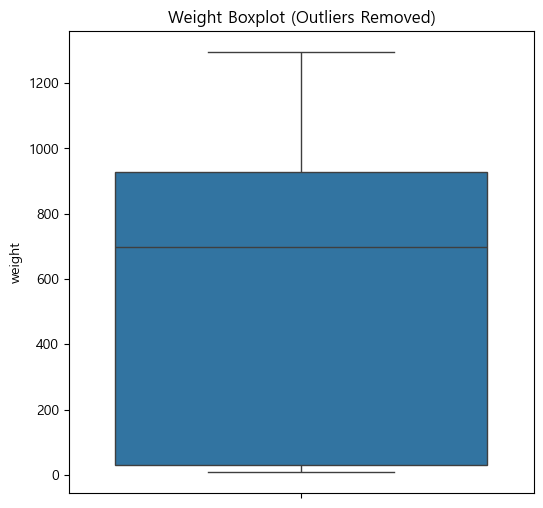

In [ ]:
df_clean = df[df['weight'] < 2500].copy() # 이상치 처리

plt.figure(figsize=(6, 6))
sns.boxplot(y=df_clean['weight'])
plt.title('Weight Boxplot (Outliers Removed)')
plt.show()

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [85]:
# 1. 독립변수(X)와 종속변수(y) 설정
# Species 컬럼 원-핫 인코딩 (get_dummies) # 범주형 변수 처리
df_encoded = pd.get_dummies(df_clean, columns=['species'])

# 데이터셋 분리 (X, y) - 'price'를 예측하고 싶으니 price는 y, 나머지는 X로 둡니다.
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# 2. 훈련 데이터와 테스트 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=198)

# 특성 스케일링 (StandardScaler 적용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"훈련 데이터 크기: {X_train_scaled.shape}")
print(f"테스트 데이터 크기: {X_test_scaled.shape}")

훈련 데이터 크기: (396, 6)
테스트 데이터 크기: (99, 6)


In [ ]:
# 1. 모델 객체 생성
model = LinearRegression()

# 2. 모델 학습 (훈련 데이터 사용)
model.fit(X_train_scaled, y_train)

# 3. 모델 예측 (테스트 데이터 사용)
y_pred = model.predict(X_test_scaled)

# 4. 모델 평가
mse = mean_squared_error(y_test, y_pred)
mae = 
(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Squared Error (MSE): 2286222.46
Mean Absolute Error (MAE): 1033.13
R-squared (R2 Score): 0.9797


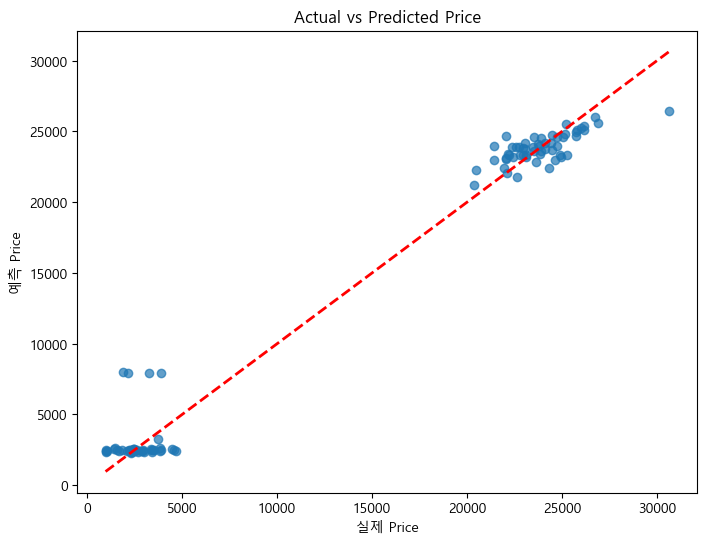

In [88]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('실제 Price')
plt.ylabel('예측 Price')
plt.title('Actual vs Predicted Price')
plt.show()

               Coefficient
length          178.242602
weight         4051.553159
height          738.000180
width            18.332262
species_bream  2928.646489
species_smelt -2928.646489


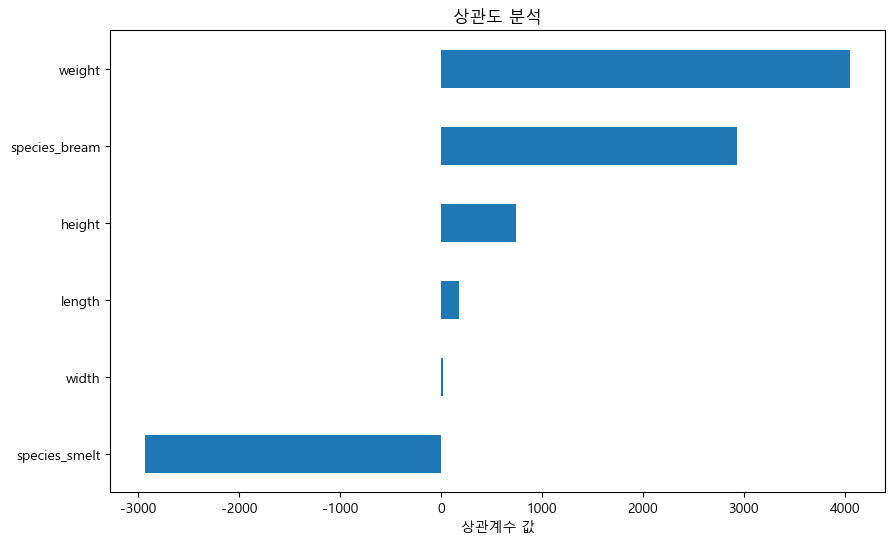

In [89]:
# 피처 이름과 계수를 매핑하여 데이터프레임으로 만들기
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

# 시각화: 어떤 변수가 중요한가?
plt.figure(figsize=(10, 6))
coefficients['Coefficient'].sort_values().plot(kind='barh')
plt.title('상관도 분석')
plt.xlabel('상관계수 값')
plt.show()

In [90]:
# 1. 새로운 데이터 정의 (사진 속 데이터)
new_data = {
    'length': [33.0],
    'weight': [850.0],
    'height': [11.5],
    'width': [4.3],
    'species': ['bream']
}
new_df = pd.DataFrame(new_data)
df_encoded = pd.get_dummies(new_df, columns=['species'])
input_data = df_encoded.reindex(columns=X.columns, fill_value=0)
input_scaled = scaler.transform(input_data)

# 2. 모델을 이용해 예측값(Price) 계산
predicted_price = model.predict(input_scaled)

print(f"최종 예측 가격: {predicted_price[0]:.2f}")

최종 예측 가격: 23370.47


--------------------------------------

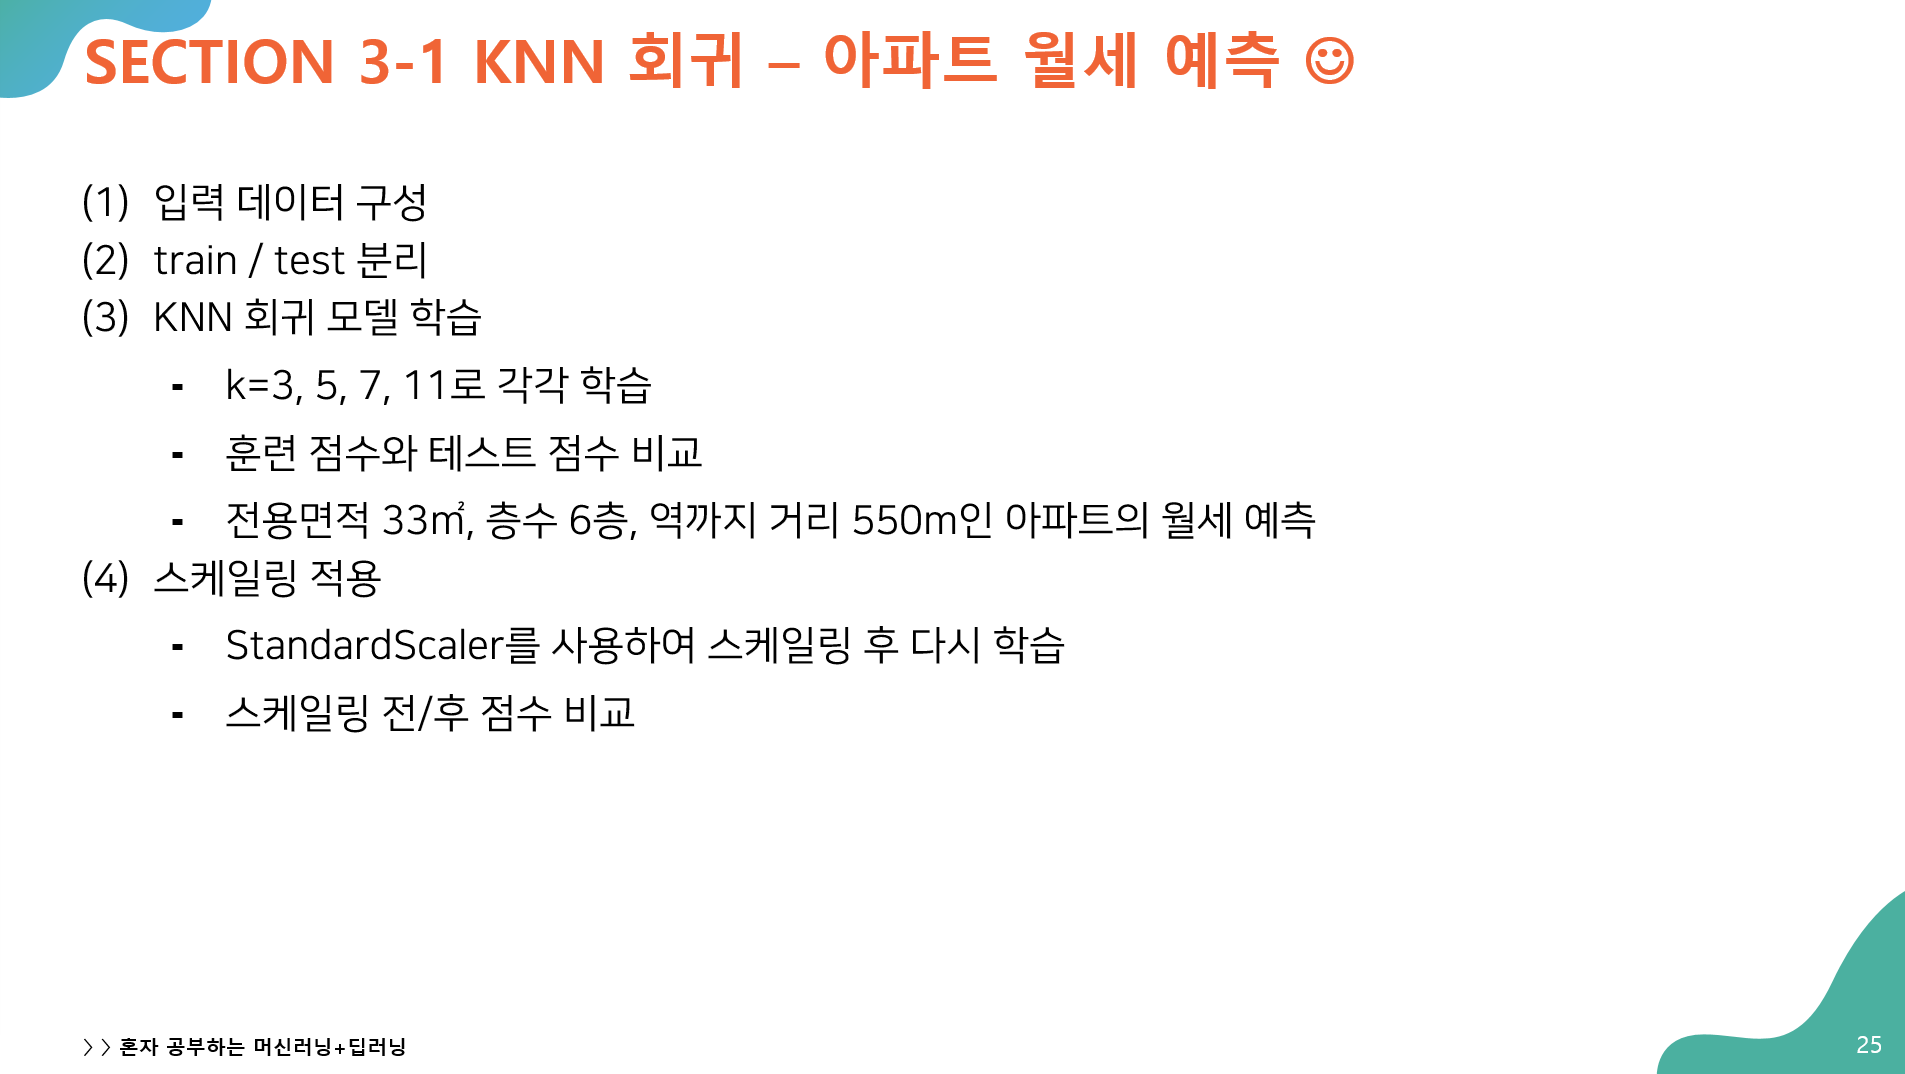

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('apartment_rent_knn.csv')
df

,area_m2,floor,distance_m,age_years,rooms,maintenance_10k,parking,elevator,district,rent_10k
0,61.0,14,358,9.7,3,11.3,0,1,0,95.0
1,75.9,7,649,13.6,4,16.0,1,0,3,111.6
2,47.3,6,587,5.9,3,14.6,0,1,3,81.2
3,33.1,9,959,5.5,2,11.1,0,1,2,68.4
4,32.3,15,278,1.1,2,9.2,1,1,2,83.0
...,...,...,...,...,...,...,...,...,...,...
495,49.8,1,1055,26.5,3,11.6,0,0,2,55.1
496,39.0,14,737,5.0,2,9.6,0,1,0,62.6
497,45.8,25,883,13.7,3,12.8,1,1,1,81.8
498,69.9,8,415,11.7,4,13.9,1,1,4,139.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area_m2          500 non-null    float64
 1   floor            500 non-null    int64  
 2   distance_m       500 non-null    int64  
 3   age_years        500 non-null    float64
 4   rooms            500 non-null    int64  
 5   maintenance_10k  500 non-null    float64
 6   parking          500 non-null    int64  
 7   elevator         500 non-null    int64  
 8   district         500 non-null    int64  
 9   rent_10k         500 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 39.2 KB


In [19]:
# rent_10k가 예측 목표
X = df.drop(columns=['rent_10k'])
y = df['rent_10k']

# 훈련/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=199)

# 2. 스케일링 준비
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. 비교할 설정들
k_values = [3, 5, 7, 11]
scaling_options = [False, True] # False: 미적용, True: 적용

results = []

# 4. 반복문을 통한 모델 학습 및 평가
for scale in scaling_options:
    for k in k_values:
        # 데이터 선택 (스케일링 여부에 따라)
        if scale:
            train_data = X_train_scaled
            test_data = X_test_scaled
        else:
            train_data = X_train
            test_data = X_test
            
        # 모델 학습 및 예측
        knn = KNeighborsRegressor(n_neighbors=k)
        knn.fit(train_data, y_train)
        # y_pred = knn.predict(test_data)
        y_pred_train = knn.predict(train_data)
        y_pred_test = knn.predict(test_data)
        
        # R2 Score 계산
        # r2 = r2_score(y_test, y_pred)
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)
        
        # 결과 저장
        results.append({
            'K Value': k,
            'Scaling': 'Yes' if scale else 'No',
            'R2 Train': r2_train,
            'R2 Test': r2_test
        })

# 5. 결과 출력 (DataFrame 형태)
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='R2 Train', ascending=False).to_string(index=False))

 K Value Scaling  R2 Train  R2 Test
       3     Yes  0.933153 0.842817
       5     Yes  0.919986 0.862174
       7     Yes  0.915787 0.858485
      11     Yes  0.902865 0.879152
       3      No  0.860028 0.657877
       5      No  0.802844 0.654584
       7      No  0.754987 0.676958
      11      No  0.663284 0.572749


In [ ]:
results_df['R2 min'] = results_df['R2 Train'] - results_df['R2 Test']
results_df['R2 min'].sort_values()
# 7번 인덱스가 차이 가장 적음 - 이 중에 이상적 모델에 가까울 것

7    0.023713
6    0.057302
5    0.057812
2    0.078029
4    0.090336
3    0.090535
1    0.148261
0    0.202151
Name: R2 min, dtype: float64

In [ ]:
results_df # k = 11, 스케일링 적용

,K Value,Scaling,R2 Train,R2 Test,R2 min
0,3,No,0.860028,0.657877,0.202151
1,5,No,0.802844,0.654584,0.148261
2,7,No,0.754987,0.676958,0.078029
3,11,No,0.663284,0.572749,0.090535
4,3,Yes,0.933153,0.842817,0.090336
5,5,Yes,0.919986,0.862174,0.057812
6,7,Yes,0.915787,0.858485,0.057302
7,11,Yes,0.902865,0.879152,0.023713


In [27]:
# rent_10k가 예측 목표
X = df.drop(columns=['rent_10k'])
y = df['rent_10k']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=199)

# # 스케일러 사용 전 / 후 비교
# # --- [모델 A: 스케일링 안 함] ---
# print("--- 스케일링 안 함 (No Scaling) ---")
# knn_no_scale = KNeighborsRegressor(n_neighbors=5)
# knn_no_scale.fit(X_train, y_train)
# y_pred_no_scale = knn_no_scale.predict(X_test)
# r2_no_scale = r2_score(y_test, y_pred_no_scale)

# print(f"R2 Score: {r2_no_scale:.4f}")

# --- [모델 B: 스케일링 함] ---
print("\n--- 스케일링 함 (With Scaling) ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsRegressor(n_neighbors=11)
knn_scaled.fit(X_train_scaled, y_train)

# 4. 새로운 데이터 예측
# 데이터 순서가 학습 데이터(X)의 컬럼 순서와 같아야 합니다.
# 컬럼: area_m2, floor, distance_m, age_years, rooms, maintenance_10k, parking, elevator, district
new_data = [[33.0, 6, 550, 10, 2, 10, 1, 1, 2]] # 값 예시: 준공 10년, 방 2개, 관리비 10만, 주차 가능 대수, 엘베 대수, 지역 2
new_df = pd.DataFrame(new_data, columns=X.columns)

# 💡 매우 중요: 새로운 데이터도 모델 학습 때 쓴 스케일러로 변환해야 함!
new_data_scaled = scaler.transform(new_df)

# 예측
predicted_rent = knn.predict(new_data_scaled)

print(f"\n[예측 결과] 전용면적 33m^2, 6층, 역까지 550m 아파트 예상 월세: {predicted_rent[0]:.2f}만 원")


--- 스케일링 함 (With Scaling) ---

[예측 결과] 전용면적 33m^2, 6층, 역까지 550m 아파트 예상 월세: 68.05만 원


In [32]:
# 예측용 샘플 5개에 대한 풀이
new_datas = [[22.0, 3, 180, 5, 1, 7.5, 0, 1, 2],
             [20.0, 10, 950, 12, 2, 11.2, 1, 1, 1],
             [38.0, 6, 420, 3, 2, 13.8, 1, 1, 4],
             [55.0, 15, 300, 18, 3, 16.5, 1, 1, 3],
             [72.0, 8, 1700, 22, 4, 14.3, 0, 1, 0]]

for i, sample in enumerate(new_datas):
    new_df2 = pd.DataFrame([sample], columns=X.columns)

    # 💡 매우 중요: 새로운 데이터도 모델 학습 때 쓴 스케일러로 변환해야 함!
    new_data_scaled = scaler.transform(new_df2)

    # 예측
    predicted_rent = knn.predict(new_data_scaled)

    print(f"\n[{i+1}번 방] 예상 월세: {predicted_rent[0]:.2f}만 원")


[1번 방] 예상 월세: 50.76만 원

[2번 방] 예상 월세: 53.07만 원

[3번 방] 예상 월세: 83.87만 원

[4번 방] 예상 월세: 90.96만 원

[5번 방] 예상 월세: 97.41만 원
